In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
import kagglehub
paultimothymooney_chest_xray_pneumonia_path = kagglehub.dataset_download('paultimothymooney/chest-xray-pneumonia')

print('Data source import complete.')

Data source import complete.


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
from skimage import img_as_float
import glob
import os
import cv2
from tqdm import tqdm
import numpy as np
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow.keras.models import Sequential , load_model
from tensorflow.keras.layers import *
from tensorflow.keras.callbacks import ModelCheckpoint
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import collections
from sklearn.utils.class_weight import compute_class_weight
from sklearn.utils import class_weight
from sklearn.metrics import classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
#from tensorflow.keras.regul

# Load Data Set from Kaggle

In [ ]:
def load_data(root_path, img_size=(128, 128), batch_size=32):
    image_paths = glob.glob(os.path.join(root_path, '*/*.jpeg')) \
            + glob.glob(os.path.join(root_path, '*/*.jpg')) \
            + glob.glob(os.path.join(root_path, '*/*.png'))

    class_names = sorted(set(os.path.basename(os.path.dirname(p)) for p in image_paths))
    class_to_index = {name: i for i, name in enumerate(class_names)}

    paths = []
    labels = []
    for path in image_paths:
        label_name = os.path.basename(os.path.dirname(path))
        paths.append(path)
        labels.append(class_to_index[label_name])

    # ✅ Fix: enforce correct dtype
    paths = np.array(paths, dtype=str)
    labels = np.array(labels, dtype=np.int32)

    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))

    def process(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, img_size)
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    dataset = dataset.map(process)
    dataset = dataset.shuffle(buffer_size=len(paths))
    dataset = dataset.batch(batch_size).prefetch(tf.data.AUTOTUNE)

    return dataset, class_names

In [ ]:
train_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"

train_ds, class_names = load_data(train_path, img_size=(128, 128), batch_size=32)
val_ds, _ = load_data(val_path, img_size=(128, 128), batch_size=32)
test_ds, _ = load_data(test_path, img_size=(128, 128), batch_size=32)

print("Classes:", class_names)

Classes: ['NORMAL', 'PNEUMONIA']


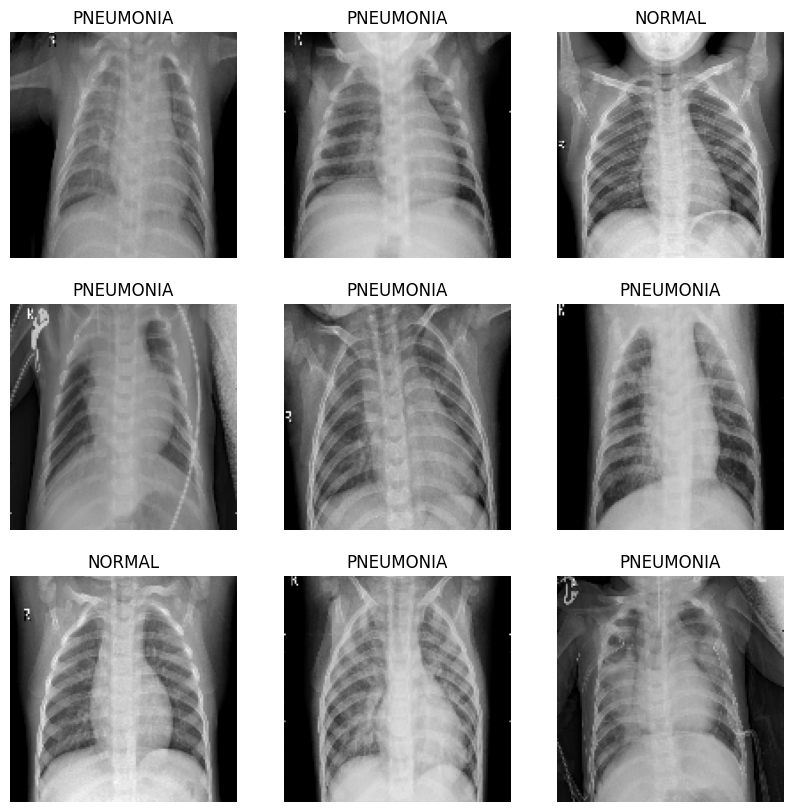

In [ ]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy())   # ✅ works with floats in [0,1]
        plt.title(class_names[int(labels[i])])
        plt.axis("off")

# Without augmentation

In [ ]:
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', strides=1, padding='same', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,288,834 (16.36 MB)

 Trainable params: 4,288,386 (16.36 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
checkpoint = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

In [ ]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
history = model.fit(
    train_ds,
    validation_data=val_ds,
    callbacks=[checkpoint],
    epochs=15
)

Epoch 1/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8775 - loss: 1.8718
Epoch 1: val_loss improved from inf to 37.65572, saving model to best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.8778 - loss: 1.8642 - val_accuracy: 0.5000 - val_loss: 37.6557
Epoch 2/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9699 - loss: 0.0873
Epoch 2: val_loss improved from 37.65572 to 18.17385, saving model to best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 392s 2s/step - accuracy: 0.9698 - loss: 0.0874 - val_accuracy: 0.5000 - val_loss: 18.1739
Epoch 3/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9738 - loss: 0.0666
Epoch 3: val_loss improved from 18.17385 to 4.23853, saving model to best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 349s 2s/step - accuracy: 0.9738 - loss: 0.0667 - val_accuracy: 0.5625 - val_loss: 4.2385
Epoch 4/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9754 - loss: 0.0723
Epoch 4: val_loss improved from 4.23853 to 0.06736, saving model to best_model.h5


163/163 ━━━━━━━━━━━━━━━━━━━━ 341s 2s/step - accuracy: 0.9754 - loss: 0.0723 - val_accuracy: 1.0000 - val_loss: 0.0674
Epoch 5/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9840 - loss: 0.0416
Epoch 5: val_loss did not improve from 0.06736
163/163 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.9840 - loss: 0.0417 - val_accuracy: 0.5625 - val_loss: 4.8390
Epoch 6/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9815 - loss: 0.0564
Epoch 6: val_loss did not improve from 0.06736
163/163 ━━━━━━━━━━━━━━━━━━━━ 385s 2s/step - accuracy: 0.9815 - loss: 0.0564 - val_accuracy: 0.5625 - val_loss: 1.1385
Epoch 7/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9860 - loss: 0.0431
Epoch 7: val_loss did not improve from 0.06736
163/163 ━━━━━━━━━━━━━━━━━━━━ 383s 2s/step - accuracy: 0.9860 - loss: 0.0431 - val_accuracy: 0.6875 - val_loss: 0.8933
Epoch 8/15
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9889 - loss: 0.0287
Epoch 8: val_loss did not improve from 0.06736


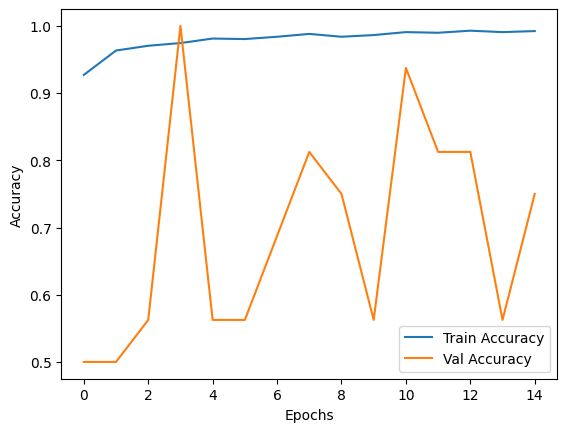

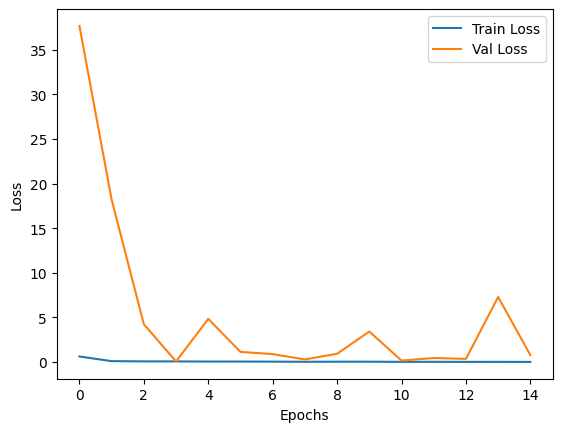

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()


In [ ]:
best_model = load_model('best_model.h5')
loss, accuracy = best_model.evaluate(test_ds)
print("Test Loss:", loss)
print("Test Accuracy:", accuracy)



20/20 ━━━━━━━━━━━━━━━━━━━━ 14s 419ms/step - accuracy: 0.7989 - loss: 0.9985
Test Loss: 1.0873980522155762
Test Accuracy: 0.7836538553237915


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 515ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 404ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 422ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 506ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 704ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 648ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 535ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 402ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 374ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 412ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 379ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 408ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 378ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 377ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 380ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 347ms/step


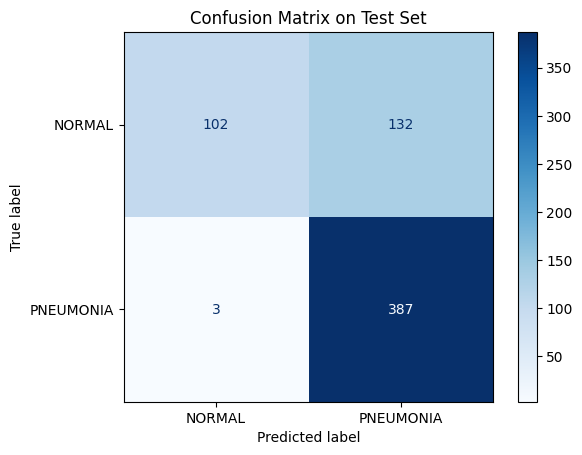

              precision    recall  f1-score   support

      NORMAL       0.97      0.44      0.60       234
   PNEUMONIA       0.75      0.99      0.85       390

    accuracy                           0.78       624
   macro avg       0.86      0.71      0.73       624
weighted avg       0.83      0.78      0.76       624



In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    preds = np.argmax(best_model.predict(images), axis=1)
    labels = labels.numpy()

    y_true.extend(labels)
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix on Test Set")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

# With class weights (Since classes are imbalance)

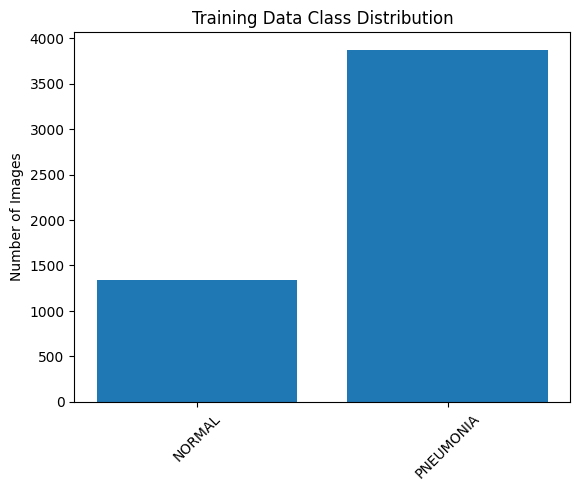

In [ ]:
label_counts = collections.Counter()

for _, labels in train_ds:
    label_counts.update(labels.numpy())

# Plot class counts
class_indices = sorted(label_counts.keys())
counts = [label_counts[i] for i in class_indices]

plt.bar([class_names[i] for i in class_indices], counts)
plt.title("Training Data Class Distribution")
plt.ylabel("Number of Images")
plt.xticks(rotation=45)
plt.show()

In [ ]:
all_train_labels = []

for _, label in train_ds.unbatch():
    all_train_labels.append(label.numpy())

all_train_labels = np.array(all_train_labels)
all_train_labels.shape

(5216,)

In [ ]:
#Calculate class weights
labels = [label.numpy() for _, label in train_ds.unbatch()]
labels = np.array(labels)

class_weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(labels),
    y=labels
)
class_weights = dict(enumerate(class_weights))

print(class_weights)

{0: np.float64(1.9448173005219984), 1: np.float64(0.6730322580645162)}


In [ ]:
#Model Architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', strides=1, padding='same', input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(2, activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,  # adjust as needed
    class_weight=class_weights,
    callbacks=[checkpoint]  )

Epoch 1/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8780 - loss: 2.0834
Epoch 1: val_loss did not improve from 0.06736
163/163 ━━━━━━━━━━━━━━━━━━━━ 333s 2s/step - accuracy: 0.8784 - loss: 2.0758 - val_accuracy: 0.5000 - val_loss: 61.7544
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9620 - loss: 0.1415
Epoch 2: val_loss did not improve from 0.06736
163/163 ━━━━━━━━━━━━━━━━━━━━ 391s 2s/step - accuracy: 0.9619 - loss: 0.1415 - val_accuracy: 0.5000 - val_loss: 33.1768
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9601 - loss: 0.1102
Epoch 3: val_loss did not improve from 0.06736
163/163 ━━━━━━━━━━━━━━━━━━━━ 328s 2s/step - accuracy: 0.9601 - loss: 0.1102 - val_accuracy: 0.5625 - val_loss: 5.0389
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.9760 - loss: 0.0756
Epoch 4: val_loss did not improve from 0.06736
163/163 ━━━━━━━━━━━━━━━━━━━━ 382s 2s/step - accuracy: 0.9760 - loss: 0.0756 - val_accuracy: 0.5000 - val_loss: 4.098

In [ ]:
loss, acc = best_model.evaluate(test_ds)
print("Test Loss:", loss)
print("Test Accuracy:", acc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 12s 424ms/step - accuracy: 0.7977 - loss: 1.0030
Test Loss: 1.0873981714248657
Test Accuracy: 0.7836538553237915


In [ ]:
print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

      NORMAL       0.97      0.44      0.60       234
   PNEUMONIA       0.75      0.99      0.85       390

    accuracy                           0.78       624
   macro avg       0.86      0.71      0.73       624
weighted avg       0.83      0.78      0.76       624



# With Augmentation

In [ ]:
train_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/train"
val_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/val"
test_path = "/kaggle/input/chest-xray-pneumonia/chest_xray/test"

In [ ]:
#Defined a generator with data augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    brightness_range=[0.8,1.2],
    fill_mode='nearest',
)

# Training Data Generator
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    subset='training',
    shuffle=True
)

# Validation Data Generator
val_datagen = ImageDataGenerator(rescale=1./255)
validation_generator = val_datagen.flow_from_directory(
    val_path,
    target_size=(128, 128),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)


Found 4173 images belonging to 2 classes.
Found 16 images belonging to 2 classes.


In [ ]:
# Model check point
checkpoint = ModelCheckpoint(
    filepath='best_model.h5',
    monitor='val_loss',
    save_best_only=True,
    mode='min',
    verbose=1
)

In [ ]:
model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,3)),
    MaxPooling2D(2,2),
    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D(2,2),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples//train_generator.batch_size,
    validation_data=validation_generator,
    validation_steps=validation_generator.samples//validation_generator.batch_size,
    epochs=10,
    class_weight=class_weights,
    callbacks=[checkpoint]
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.4647 - loss: 0.6813
Epoch 1: val_loss improved from inf to 0.49828, saving model to best_model.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 193s 1s/step - accuracy: 0.4655 - loss: 0.6811 - val_accuracy: 0.7500 - val_loss: 0.4983
Epoch 2/10
  1/130 ━━━━━━━━━━━━━━━━━━━━ 1:52 875ms/step - accuracy: 0.8125 - loss: 0.4298

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()



Epoch 2: val_loss improved from 0.49828 to 0.48537, saving model to best_model.h5


...

130/130 ━━━━━━━━━━━━━━━━━━━━ 196s 1s/step - accuracy: 0.7286 - loss: 0.5367 - val_accuracy: 0.8750 - val_loss: 0.4260
Epoch 4/10
  1/130 ━━━━━━━━━━━━━━━━━━━━ 1:51 861ms/step - accuracy: 0.8125 - loss: 0.6580
Epoch 4: val_loss improved from 0.42597 to 0.42324, saving model to best_model.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8125 - loss: 0.6580 - val_accuracy: 0.8750 - val_loss: 0.4232
Epoch 5/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8083 - loss: 0.4165
Epoch 5: val_loss improved from 0.42324 to 0.38456, saving model to best_model.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 188s 1s/step - accuracy: 0.8083 - loss: 0.4164 - val_accuracy: 0.9375 - val_loss: 0.3846
Epoch 6/10
  1/130 ━━━━━━━━━━━━━━━━━━━━ 1:50 856ms/step - accuracy: 0.9062 - loss: 0.1393
Epoch 6: val_loss did not improve from 0.38456
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9062 - loss: 0.1393 - val_accuracy: 0.7500 - val_loss: 0.4661
Epoch 7/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8477 - loss: 0.3523
Epoch 7: val_loss improved from 0.38456 to 0.31754, saving model to best_model.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 203s 1s/step - accuracy: 0.8477 - loss: 0.3521 - val_accuracy: 0.9375 - val_loss: 0.3175
Epoch 8/10
  1/130 ━━━━━━━━━━━━━━━━━━━━ 1:50 860ms/step - accuracy: 0.9062 - loss: 0.3085
Epoch 8: val_loss did not improve from 0.31754
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9062 - loss: 0.3085 - val_accuracy: 0.8750 - val_loss: 0.3298
Epoch 9/10
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.8556 - loss: 0.3183
Epoch 9: val_loss improved from 0.31754 to 0.23113, saving model to best_model.h5


130/130 ━━━━━━━━━━━━━━━━━━━━ 198s 1s/step - accuracy: 0.8556 - loss: 0.3182 - val_accuracy: 0.8750 - val_loss: 0.2311
Epoch 10/10
  1/130 ━━━━━━━━━━━━━━━━━━━━ 1:51 861ms/step - accuracy: 0.7500 - loss: 0.6013
Epoch 10: val_loss did not improve from 0.23113
130/130 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7500 - loss: 0.6013 - val_accuracy: 0.8750 - val_loss: 0.2376


In [ ]:
model.save("best_model.h5")
best_model = load_model("best_model.h5")
loss, acc = best_model.evaluate(test_ds)

20/20 ━━━━━━━━━━━━━━━━━━━━ 11s 250ms/step - accuracy: 0.8299 - loss: 0.3867


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 351ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 294ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 503ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 482ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 388ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 280ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 302ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 299ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 279ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 281ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 290ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 277ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 283ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step


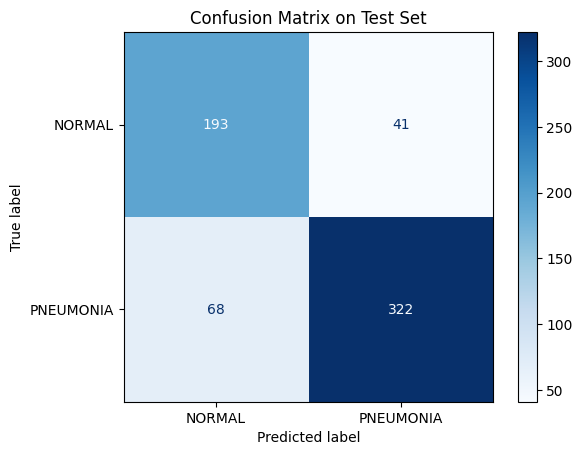

              precision    recall  f1-score   support

      NORMAL       0.74      0.82      0.78       234
   PNEUMONIA       0.89      0.83      0.86       390

    accuracy                           0.83       624
   macro avg       0.81      0.83      0.82       624
weighted avg       0.83      0.83      0.83       624



In [ ]:
y_true = []
y_pred = []

for images, labels in test_ds:
    probs = best_model.predict(images)  # shape (batch_size, 1)
    preds = (probs > 0.5).astype(int).flatten()  # binary labels
    y_true.extend(labels.numpy())
    y_pred.extend(preds)

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix on Test Set")
plt.show()

print(classification_report(y_true, y_pred, target_names=class_names))

# Test Accuracy

Without augmentation - 0.783653

With Class weights - 0.783653

With augmentation - 0.8299